In [ ]:
import requests
# 需要配置好预训练模型路径
CHECKPOINT_PATHS = {
    'random': './random/checkpoint-best.pth',
    'attn':   './attn/checkpoint-best.pth',
    'edge':   './edge/checkpoint-best.pth',
}

# 需要配置好测试图片路径
IMAGE_SOURCES = [
    'https://user-images.githubusercontent.com/11435359/147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg',
    'https://user-images.githubusercontent.com/11435359/147743081-0428eecf-89e5-4e07-8da5-a30fd73cc0ba.jpg',
    '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train/n01440764/n01440764_10043.JPEG',
    '/kaggle/input/datasets/ifigotin/imagenetmini-1000/imagenet-mini/train/n01440764/n01440764_10744.JPEG',
]

# 需要配置好保存路径
SAVE_PATH = './output/batch_recon_vis_result.png'

import os
os.makedirs('./output/', exist_ok=True)

In [ ]:
# --- 对应 main_pretrain.py: parser.add_argument('--img_size', default=224) ---
IMG_SIZE    = 224

# --- 对应 main_pretrain.py: parser.add_argument('--patch_size', default=16) ---
PATCH_SIZE  = 16

# --- 对应 main_pretrain.py: parser.add_argument('--encoder_dim', default=768) ---
ENCODER_DIM   = 768

# --- 对应 main_pretrain.py: parser.add_argument('--encoder_depth', default=16) ---
ENCODER_DEPTH = 16

# --- 对应 main_pretrain.py: parser.add_argument('--encoder_num_heads', default=16) ---
ENCODER_HEADS = 16

# --- 对应 main_pretrain.py: parser.add_argument('--decoder_dim', default=512) ---
DECODER_DIM   = 512

# --- 对应 main_pretrain.py: parser.add_argument('--decoder_depth', default=6) ---
DECODER_DEPTH = 6

# --- 对应 main_pretrain.py: parser.add_argument('--decoder_num_heads', default=16) ---
DECODER_HEADS = 16

# --- 对应 main_pretrain.py: parser.add_argument('--mask_ratio', default=0.75) ---
MASK_RATIO  = 0.75

# --- 对应 main_pretrain.py: parser.set_defaults(norm_pix_loss=False) ---
# 必须与训练时 --norm_pix_loss 开关一致
NORM_PIX_LOSS = False

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

from my_vit import MyVit
from my_mae import MyMaskedAutoencoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

使用设备: cpu


In [6]:
def unpatchify(x, patch_size=16):
    """
    将模型输出的 patch 序列还原成完整图像张量。
    必须与 my_vit.py 的 patch_embed[0] (Rearrange) 严格互逆：
        patch_embed[0]: 'n c (x p1) (y p2) -> n (x y) (c p1 p2)'
    输入 x : [B, L, patch_size**2 * C]
    输出   : [B, C, H, W]
    """
    B, L, _ = x.shape
    p = patch_size
    h = w = int(L ** 0.5)
    assert h * w == L

    x = x.reshape(B, h, w, 3, p, p)
    x = x.permute(0, 3, 1, 4, 2, 5).contiguous()
    imgs = x.reshape(B, 3, h * p, w * p)
    return imgs


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def inverse_imagenet_normalize(t):
    """
    将 ImageNet 归一化后的 tensor 还原到 [0,1] 显示范围。
    对应 main_pretrain.py transforms.Normalize 的逆操作。
    输入 t: [C, H, W]，输出: [C, H, W]，值域 [0, 1]
    """
    mean = IMAGENET_MEAN.to(t.device)
    std  = IMAGENET_STD.to(t.device)
    return (t * std + mean).clamp(0, 1)

In [7]:
# 去掉随机增强，保留归一化，对应 main_pretrain.py 的 transform_train
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

In [ ]:
models = {}

for mask_type, ckpt_path in CHECKPOINT_PATHS.items():
    encoder = MyVit(
        img_size   = IMG_SIZE,
        patch_size = PATCH_SIZE,
        embed_dim  = ENCODER_DIM,
        depth      = ENCODER_DEPTH,
        num_heads  = ENCODER_HEADS,
    )
    model = MyMaskedAutoencoder(
        encoder           = encoder,
        mask_type         = mask_type,       # 对应各策略预训练时的 --mask_type
        mask_ratio        = MASK_RATIO,
        decoder_dim       = DECODER_DIM,
        decoder_depth     = DECODER_DEPTH,
        decoder_num_heads = DECODER_HEADS,
        norm_pix_loss     = NORM_PIX_LOSS,
    )

    checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    state_dict = checkpoint['model']

    # 处理 DDP 训练产生的 'module.' 前缀
    if any(k.startswith('module.') for k in state_dict.keys()):
        state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

    msg = model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()

    models[mask_type] = model
    print(f'[{mask_type}] 加载完成，路径: {ckpt_path}')

[random] 加载完成，路径: /kaggle/input/models/aaa290/mae-random-100epoch/transformers/default/4/output/checkpoint-best.pth
[attn] 加载完成，路径: /kaggle/input/models/aaa290/mae-random-100epoch/transformers/default/7/output/checkpoint-best.pth
[edge] 加载完成，路径: /kaggle/input/models/aaa290/mae-random-100epoch/transformers/default/8/output/checkpoint-best.pth


In [ ]:
# 推理逻辑与原始代码完全一致：forward → 反patch标准化 → unpatchify → 反ImageNet归一化 → 合成masked图
def reconstruct_single(img_tensor, model):
    """
    对单张预处理好的图片 tensor 做一次完整推理，返回三张可视化用 numpy 图。

    参数：
        img_tensor : [1, C, H, W]，已完成 transform 的图片 tensor，在 device 上
        model      : 已加载权重并 .eval() 的 MyMaskedAutoencoder 实例

    返回：
        original_np : [H, W, 3]，原图（反归一化后）
        im_masked   : [H, W, 3]，灰色遮盖版（mask 区域填 0.5）
        im_paste    : [H, W, 3]，重建合成版（mask 区域用模型预测填充）
    """
    with torch.no_grad():
        # my_mae.py forward() 返回: loss, mean, var, pred, mask
        # pred  : [B, L, patch_size**2 * 3]，模型预测的 patch 像素
        # mask  : [B, L]，0=保留，1=被遮盖
        # mean/var: 用于反 patch 标准化（norm_pix_loss=False 时为 0/1）
        loss, mean, var, pred, mask = model(img_tensor)

    # 步骤 A：反「patch 标准化」（对应 forward_loss 中的 norm_pix_loss 分支）
    # norm_pix_loss=False 时 mean=0, var=1，此步为恒等变换
    pred_unnorm = pred * (var + 1.e-6) ** 0.5 + mean

    # 步骤 B：patch 序列还原为图像（必须与 my_vit.py patch_embed[0] 的 Rearrange 严格互逆）
    pred_img = unpatchify(pred_unnorm, PATCH_SIZE)           # [1, 3, 224, 224]

    # 步骤 C：反 ImageNet 归一化，还原到 [0,1] 显示空间
    original_display = inverse_imagenet_normalize(img_tensor[0])  # [3, 224, 224]
    pred_display     = inverse_imagenet_normalize(pred_img[0])     # [3, 224, 224]
    original_np = original_display.cpu().permute(1, 2, 0).numpy()
    pred_np     = pred_display.cpu().permute(1, 2, 0).numpy()

    # 步骤 D：生成像素级 mask
    # mask [1, L] → 扩展到每个 patch 内所有像素 → unpatchify → 像素级 [H, W, 3]
    mask_patches = mask.unsqueeze(-1).repeat(1, 1, PATCH_SIZE ** 2 * 3)
    mask_img     = unpatchify(mask_patches.float(), PATCH_SIZE)
    mask_np      = mask_img[0].cpu().permute(1, 2, 0).numpy()

    # 合成：保留区域显示原图，遮盖区域显示灰色（0.5）
    im_masked = original_np * (1 - mask_np) + 0.5 * mask_np
    # 合成：保留区域用原图像素，遮盖区域用模型预测（对应 loss 只算 mask==1 区域）
    im_paste  = original_np * (1 - mask_np) + pred_np * mask_np

    original_np = np.clip(original_np, 0, 1)
    im_masked   = np.clip(im_masked,   0, 1)
    im_paste    = np.clip(im_paste,    0, 1)

    return original_np, im_masked, im_paste, loss.item()

In [10]:
# 双层循环，外层遍历图片，内层遍历三个模型
# 结果存入嵌套字典：results[img_path][mask_type] = (original_np, im_masked, im_paste, loss)

results = {}
for img_source in IMAGE_SOURCES:
    if img_source.startswith('http'):
        img_pil = Image.open(requests.get(img_source, stream=True).raw).convert('RGB')
    else:
        img_pil = Image.open(img_source).convert('RGB')

    x = transform(img_pil).unsqueeze(0).to(device)
    results[img_source] = {}
    for mask_type, model in models.items():
        original_np, im_masked, im_paste, loss_val = reconstruct_single(x, model)
        results[img_source][mask_type] = (original_np, im_masked, im_paste, loss_val)  
        print(f'  [{mask_type}] loss={loss_val:.4f}')
    print(f'图片完成: {img_source.split("/")[-1]}') 

  [random] loss=0.2589
  [attn] loss=0.4002
  [edge] loss=0.3209
图片完成: 147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg
  [random] loss=0.3649
  [attn] loss=0.5026
  [edge] loss=0.3398
图片完成: 147743081-0428eecf-89e5-4e07-8da5-a30fd73cc0ba.jpg
  [random] loss=0.3402
  [attn] loss=0.3236
  [edge] loss=0.4266
图片完成: n01440764_10043.JPEG
  [random] loss=0.0884
  [attn] loss=0.0768
  [edge] loss=0.1225
图片完成: n01440764_10744.JPEG


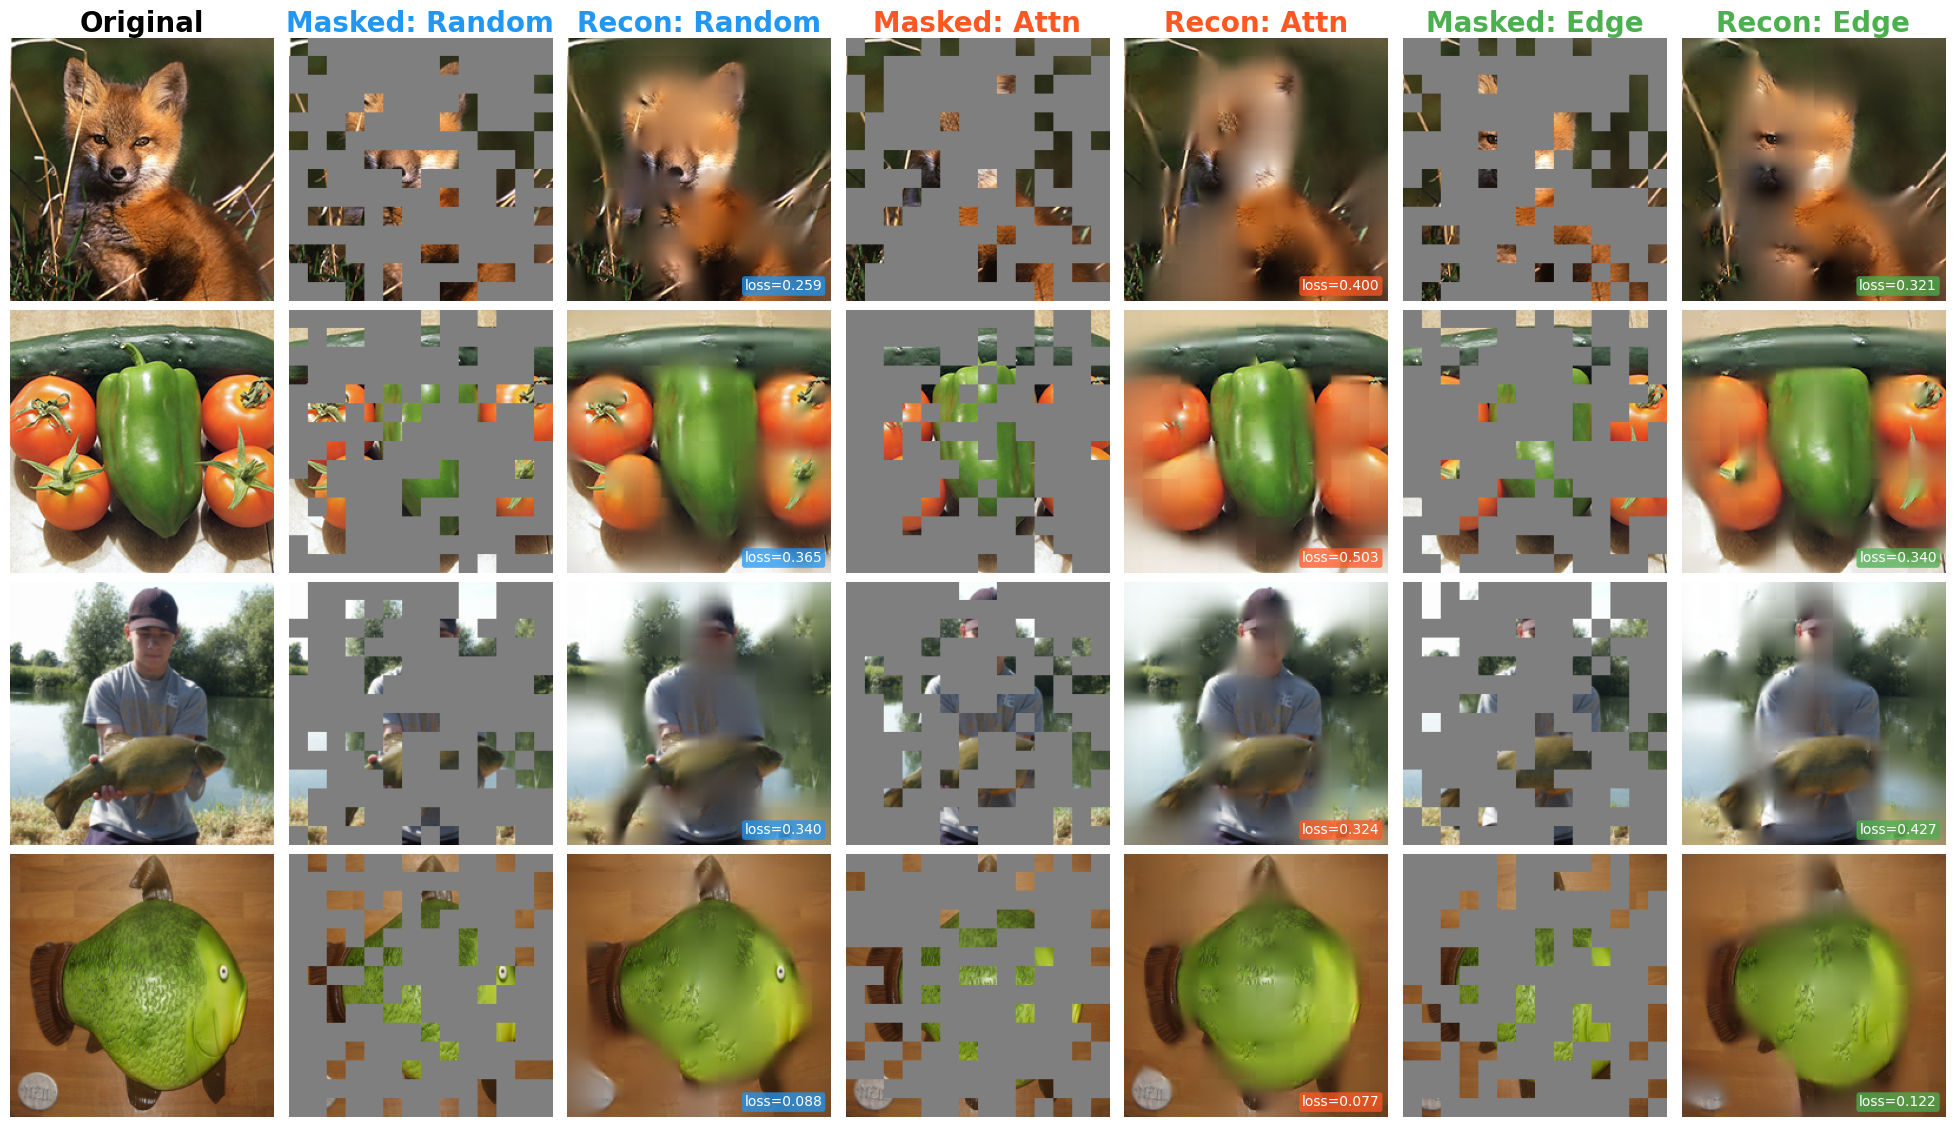

批量图表生成完毕！已保存至：/kaggle/working/output/batch_recon_vis_result.png


In [ ]:
# 列顺序（7列）：
#   0: Original
#   1: Masked (Random)    2: Recon (Random)
#   3: Masked (Attn)      4: Recon (Attn)
#   5: Masked (Edge)      6: Recon (Edge)
#
# 行顺序：每张输入图片占一行

MASK_TYPES   = ['random', 'attn', 'edge']
N_IMGS       = len(IMAGE_SOURCES)
N_COLS       = 1 + len(MASK_TYPES) * 2   # 7 列

# 列标题
COL_TITLES = [
    'Original',
    'Masked: Random', 'Recon: Random',
    'Masked: Attn',   'Recon: Attn',
    'Masked: Edge',   'Recon: Edge',
]

# 颜色区分三个策略组（和分割可视化标题颜色一致的风格）
STRATEGY_COLORS = {
    'random': '#2196F3',   # 蓝
    'attn':   '#FF5722',   # 橙红
    'edge':   '#4CAF50',   # 绿
}

fig, axes = plt.subplots(
    N_IMGS, N_COLS,
    figsize=(N_COLS * 2.8, N_IMGS * 2.8),
)

# 保证 axes 始终是二维数组，方便统一索引
if N_IMGS == 1:
    axes = axes[np.newaxis, :]

# 第一行写列标题
for col_idx, title in enumerate(COL_TITLES):
    ax = axes[0, col_idx]
    if col_idx == 0:
        color = 'black'
    elif col_idx in [1, 2]:
        color = STRATEGY_COLORS['random']
    elif col_idx in [3, 4]:
        color = STRATEGY_COLORS['attn']
    else:
        color = STRATEGY_COLORS['edge']
    ax.set_title(title, fontsize=20, fontweight='bold', color=color, pad=4)

# 填充每格图片
for row_idx, img_source in enumerate(IMAGE_SOURCES):
    img_results = results[img_source]

    # 行标签（图片文件名，显示在最左格的 ylabel）
    axes[row_idx, 0].set_ylabel(
        img_source.split("/")[-1][:25],   # 截断避免过长
        fontsize=7, color='gray', rotation=0,
        ha='right', va='center', labelpad=4
    )

    col_idx = 0
    original_np = img_results['random'][0]   # 三个模型的 original_np 相同，取其一

    # 列0：原图
    axes[row_idx, col_idx].imshow(original_np)
    axes[row_idx, col_idx].axis('off')
    col_idx += 1

    # 列1-6：三个策略各占两列（Masked + Recon）
    for mask_type in MASK_TYPES:
        _, im_masked, im_paste, loss_val = img_results[mask_type]

        # Masked 列
        axes[row_idx, col_idx].imshow(im_masked)
        axes[row_idx, col_idx].axis('off')
        col_idx += 1

        # Recon 列（在图片右下角注释 loss 值）
        axes[row_idx, col_idx].imshow(im_paste)
        axes[row_idx, col_idx].text(
            0.97, 0.03, f'loss={loss_val:.3f}',
            transform=axes[row_idx, col_idx].transAxes,
            fontsize=10, color='white',
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor=STRATEGY_COLORS[mask_type],
                      alpha=0.75, edgecolor='none')
        )
        axes[row_idx, col_idx].axis('off')
        col_idx += 1

plt.tight_layout(pad=0.5, h_pad=0.8, w_pad=0.3)
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'批量图表生成完毕！已保存至：{SAVE_PATH}')